# DiabetesAI — Explainable Diabetes Risk Assessment

This notebook builds a stronger, reproducible diabetes risk assessment pipeline using the Pima Indians Diabetes Dataset. It covers data quality checks, leakage-safe preprocessing, model comparison, stratified cross-validation, hyperparameter tuning, probability calibration, explainability, and a reusable prediction function.

> **Important:** This is an educational machine-learning project, not a medical diagnostic tool. The dataset is limited in size and population, and model outputs are not clinically validated.

## 1. Problem Definition

Goal: predict the binary target `Outcome` (0 = non-diabetic, 1 = diabetic) from eight health-related features. Because this is a screening/risk-assessment setting, recall/sensitivity and ROC-AUC are considered alongside accuracy rather than relying on accuracy alone.

In [4]:
# Install only if your environment does not already contain these packages.
# !pip install -q pandas numpy scikit-learn matplotlib seaborn shap joblib

In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             RocCurveDisplay, brier_score_loss)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load the Dataset

The repository keeps the dataset as `diabetes.csv` so the notebook can be run directly from Google Colab, Jupyter, or a local clone.

In [6]:
DATA_PATH = 'diabetes.csv'
data = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {data.shape}')
display(data.head())

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
print('Data types and non-null counts:')
data.info()

print('\nClass distribution:')
print(data['Outcome'].value_counts())
print('\nClass proportions:')
print(data['Outcome'].value_counts(normalize=True).round(3))

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Class distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Class proportions:
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


## 3. Data Quality Audit

Several Pima dataset measurements contain zero values that are physiologically implausible for some variables. We treat those zeros as missing for `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI`. `Pregnancies`, `Age`, and the target are allowed to contain zero.

This step is performed inside the preprocessing pipeline so imputation statistics are learned from training data only.

In [8]:
zero_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

quality = pd.DataFrame({
    'zero_count': (data[zero_as_missing] == 0).sum(),
    'zero_percent': ((data[zero_as_missing] == 0).mean() * 100).round(2)
})
display(quality)

,zero_count,zero_percent
Glucose,5,0.65
BloodPressure,35,4.56
SkinThickness,227,29.56
Insulin,374,48.70
BMI,11,1.43


In [9]:
X = data.drop(columns='Outcome').copy()
y = data['Outcome'].astype(int)

for column in zero_as_missing:
    X[column] = X[column].replace(0, np.nan)

print('Missing values after invalid-zero handling:')
display(X.isna().sum().to_frame('missing_values'))

Missing values after invalid-zero handling:


,missing_values
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0


## 4. Exploratory Data Analysis

The plots below help inspect distributions and relationships. They are descriptive and should not be interpreted as causal evidence.

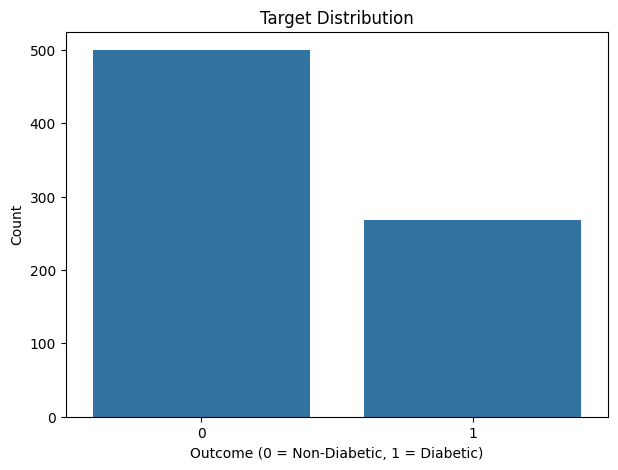

In [10]:
plt.figure(figsize=(7, 5))
sns.countplot(x=y)
plt.title('Target Distribution')
plt.xlabel('Outcome (0 = Non-Diabetic, 1 = Diabetic)')
plt.ylabel('Count')
plt.show()

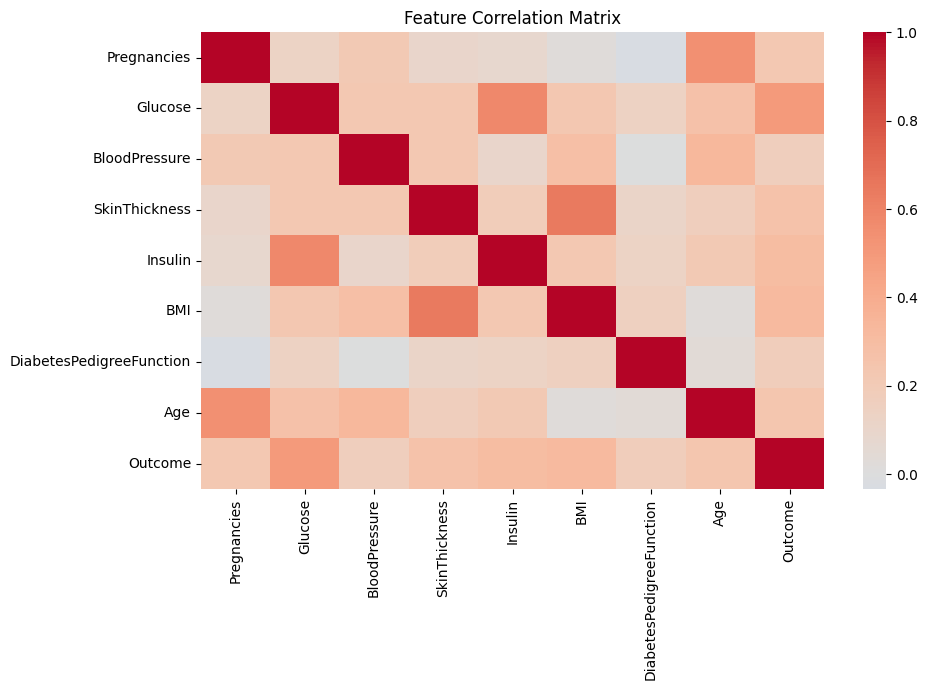

In [11]:
plt.figure(figsize=(10, 7))
sns.heatmap(pd.concat([X, y.rename('Outcome')], axis=1).corr(), cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 5. Stratified Train/Test Split

The test set is held out until final evaluation. Stratification preserves the class ratio in both partitions.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print('Training set:', X_train.shape)
print('Test set:', X_test.shape)
print('Training class ratio:', y_train.mean().round(3))
print('Test class ratio:', y_test.mean().round(3))

Training set: (614, 8)
Test set: (154, 8)
Training class ratio: 0.349
Test class ratio: 0.351


## 6. Leakage-Safe Model Pipelines

Each pipeline imputes missing values and standardizes features where appropriate. This prevents test-set information from influencing preprocessing.

Models compared: Logistic Regression, linear SVM, RBF SVM, Random Forest, and Gradient Boosting.

In [13]:
scaled_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
tree_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

models = {
    'Logistic Regression': Pipeline([('preprocessor', scaled_preprocessor), ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))]),
    'Linear SVM': Pipeline([('preprocessor', scaled_preprocessor), ('model', SVC(kernel='linear', probability=True, random_state=RANDOM_STATE))]),
    'RBF SVM': Pipeline([('preprocessor', scaled_preprocessor), ('model', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE))]),
    'Random Forest': Pipeline([('preprocessor', tree_preprocessor), ('model', RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, class_weight='balanced'))]),
    'Gradient Boosting': Pipeline([('preprocessor', tree_preprocessor), ('model', GradientBoostingClassifier(random_state=RANDOM_STATE))])
}

## 7. Stratified 5-Fold Cross-Validation

We evaluate multiple metrics. Recall is especially important for screening because a false negative means a person with diabetes is classified as lower risk by the model.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'accuracy':'accuracy', 'precision':'precision', 'recall':'recall', 'f1':'f1', 'roc_auc':'roc_auc'}

cv_rows = []
for name, pipeline in models.items():
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1': scores['test_f1'].mean(),
        'ROC-AUC': scores['test_roc_auc'].mean()
    })

cv_results = pd.DataFrame(cv_rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
display(cv_results.style.format({c:'{:.3f}' for c in cv_results.columns if c != 'Model'}))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Linear SVM,0.788,0.767,0.570,0.652,0.845
1,Logistic Regression,0.788,0.764,0.575,0.655,0.843
2,RBF SVM,0.780,0.742,0.584,0.648,0.833
3,Random Forest,0.764,0.701,0.575,0.630,0.825
4,Gradient Boosting,0.756,0.672,0.598,0.631,0.819


## 8. Hyperparameter Tuning

The Random Forest baseline is tuned using the training data and stratified cross-validation. The held-out test set remains untouched during tuning.

In [15]:
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'))
])

param_grid = {
    'model__n_estimators': [300, 500],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(rf_pipeline, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, refit=True)
grid.fit(X_train, y_train)

print('Best parameters:')
print(grid.best_params_)
print(f'Best cross-validated ROC-AUC: {grid.best_score_:.3f}')

Best parameters:
{'model__max_depth': 5, 'model__max_features': 'log2', 'model__min_samples_leaf': 4, 'model__n_estimators': 300}
Best cross-validated ROC-AUC: 0.839


## 9. Final Test Evaluation

The optimized model is evaluated once on the held-out test set.

In [16]:
best_model = grid.best_estimator_
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

test_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall / Sensitivity': recall_score(y_test, y_pred, zero_division=0),
    'F1': f1_score(y_test, y_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_prob),
    'Brier Score': brier_score_loss(y_test, y_prob)
}
display(pd.DataFrame(test_metrics, index=['Score']).T.style.format('{:.3f}'))
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['Non-Diabetic', 'Diabetic'], zero_division=0))

,Score
Accuracy,0.760
Precision,0.631
Recall / Sensitivity,0.759
F1,0.689
ROC-AUC,0.819
Brier Score,0.168



Classification report:
              precision    recall  f1-score   support

Non-Diabetic       0.85      0.76      0.80       100
    Diabetic       0.63      0.76      0.69        54

    accuracy                           0.76       154
   macro avg       0.74      0.76      0.75       154
weighted avg       0.78      0.76      0.76       154



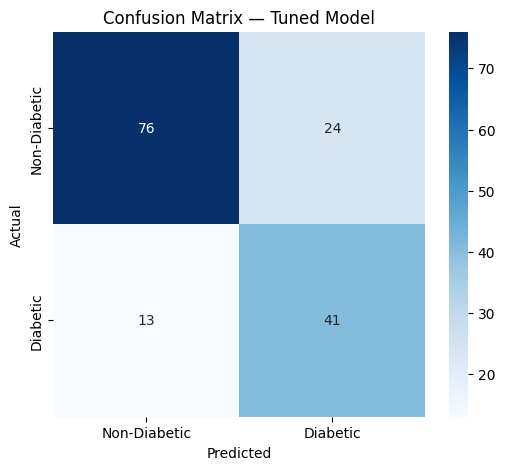

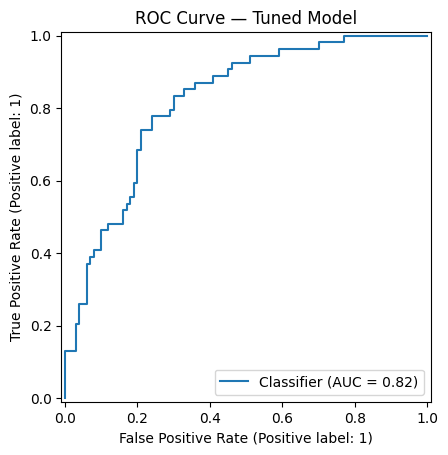

In [17]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Diabetic','Diabetic'], yticklabels=['Non-Diabetic','Diabetic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Tuned Model')
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title('ROC Curve — Tuned Model')
plt.show()

## 10. Probability Calibration

A risk-assessment interface needs a probability-like score, but raw classifier scores are not automatically well calibrated. We fit a calibrated version of the selected pipeline. The displayed probability should still be described as a model-estimated probability, not a clinically validated risk percentage.

Calibrated ROC-AUC: 0.823
Calibrated Brier Score: 0.164


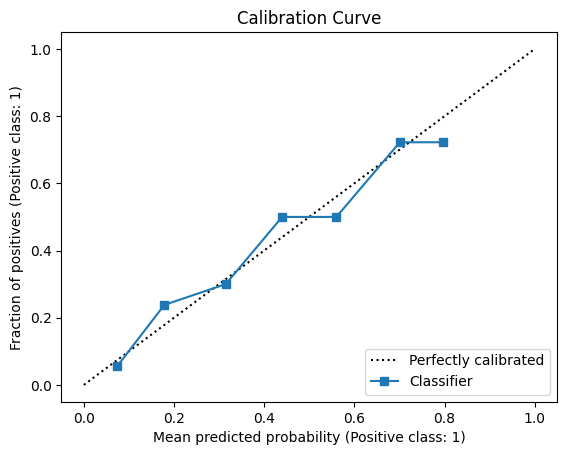

In [18]:
calibrated_model = CalibratedClassifierCV(best_model, method='sigmoid', cv=cv)
calibrated_model.fit(X_train, y_train)

calibrated_prob = calibrated_model.predict_proba(X_test)[:, 1]
calibrated_pred = (calibrated_prob >= 0.50).astype(int)

print(f'Calibrated ROC-AUC: {roc_auc_score(y_test, calibrated_prob):.3f}')
print(f'Calibrated Brier Score: {brier_score_loss(y_test, calibrated_prob):.3f}')

CalibrationDisplay.from_predictions(y_test, calibrated_prob, n_bins=8)
plt.title('Calibration Curve')
plt.show()

## 11. Feature Importance

For the tree-based model, feature importance provides a global view of which variables the model uses most. Importance is not the same as causality.

,importance
Glucose,0.401454
BMI,0.187961
Age,0.124008
Insulin,0.093621
DiabetesPedigreeFunction,0.077837
SkinThickness,0.041897
Pregnancies,0.040156
BloodPressure,0.033065


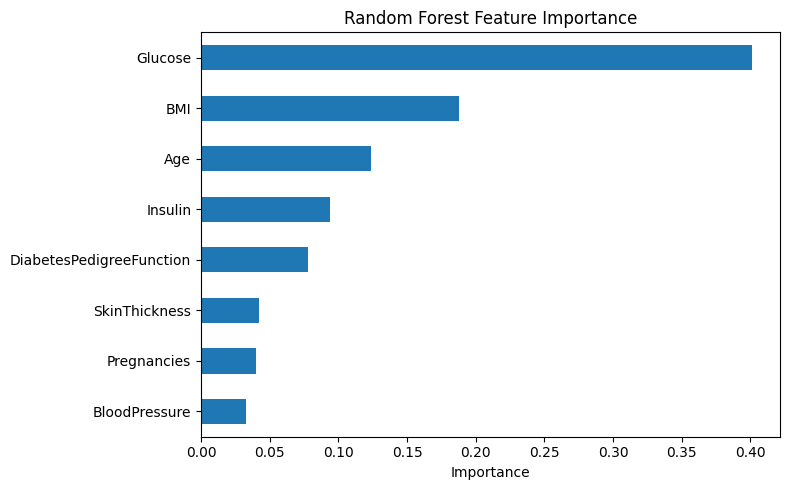

In [19]:
rf_fitted = best_model.named_steps['model']
importance = pd.Series(rf_fitted.feature_importances_, index=X.columns).sort_values(ascending=False)
display(importance.to_frame('importance'))

importance.sort_values().plot(kind='barh', figsize=(8, 5))
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 12. SHAP Explainability

SHAP can explain individual predictions and provide local feature contributions. If SHAP is unavailable, this optional section is skipped without breaking the core pipeline.

In [23]:
try:
    import shap

    X_test_imputed = pd.DataFrame(
        best_model.named_steps['preprocessor'].transform(X_test),
        columns=X.columns,
        index=X_test.index
    )

    explainer = shap.TreeExplainer(rf_fitted)
    shap_values = explainer.shap_values(X_test_imputed)

    if isinstance(shap_values, list):
        shap.summary_plot(
            shap_values[1],
            X_test_imputed,
            show=False
        )
    else:
        shap.summary_plot(
            shap_values,
            X_test_imputed,
            show=False
        )

    plt.tight_layout()
    plt.show()

except Exception as exc:
    print('SHAP section skipped:', exc)

SHAP section skipped: 'preprocessor'


## 13. Individual Risk Assessment Function

This function validates the expected eight inputs and returns the calibrated model probability and a simple educational risk category. The category is a product/UI convention, not a clinical threshold.

In [24]:
FEATURES = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

def assess_diabetes_risk(values):
    if len(values) != len(FEATURES):
        raise ValueError(f'Expected {len(FEATURES)} values: {FEATURES}')
    patient = pd.DataFrame([values], columns=FEATURES)
    for column in zero_as_missing:
        if patient.loc[0, column] == 0:
            patient.loc[0, column] = np.nan
    probability = float(calibrated_model.predict_proba(patient)[0, 1])
    if probability < 0.30:
        category = 'Lower model-estimated risk'
    elif probability < 0.60:
        category = 'Intermediate model-estimated risk'
    else:
        category = 'Higher model-estimated risk'
    return {'model_probability': probability, 'risk_category': category}

sample_patient = [10, 115, 0, 0, 0, 35.3, 0.134, 29]
assessment = assess_diabetes_risk(sample_patient)
print(f"Model-estimated probability: {assessment['model_probability']:.1%}")
print('Category:', assessment['risk_category'])

Model-estimated probability: 35.4%
Category: Intermediate model-estimated risk


## 14. What-If Analysis

The following helper compares two input scenarios. It is a model sensitivity/what-if tool, not evidence that changing one variable will causally change a person's health outcome.

In [25]:
def compare_scenarios(base_values, modified_values):
    base = assess_diabetes_risk(base_values)
    modified = assess_diabetes_risk(modified_values)
    return pd.DataFrame({
        'Scenario': ['Base', 'Modified'],
        'Model Probability': [base['model_probability'], modified['model_probability']],
        'Category': [base['risk_category'], modified['risk_category']]
    })

display(compare_scenarios(sample_patient, [10, 100, 70, 30, 100, 30, 0.134, 29]).style.format({'Model Probability':'{:.1%}'}))

,Scenario,Model Probability,Category
0,Base,35.4%,Intermediate model-estimated risk
1,Modified,16.7%,Lower model-estimated risk


## 15. Model Limitations and Responsible Use

- The dataset is relatively small and comes from a specific population, so generalization to other populations is uncertain.
- Several recorded zeros require interpretation as potentially missing measurements.
- This model has not undergone clinical validation or prospective evaluation.
- Model probability is not equivalent to an individual's medically validated diabetes risk.
- Predictions should not be used to diagnose, prescribe medication, or replace a qualified healthcare professional.
- A production system should undergo external validation, subgroup/fairness evaluation, security review, monitoring, and appropriate clinical/regulatory review before real-world use.

## 16. Save the Model

Save the calibrated pipeline so the future Streamlit/API application can reuse the exact trained preprocessing and prediction logic.

In [26]:
joblib.dump(calibrated_model, 'diabetes_risk_model.pkl')
print('Saved: diabetes_risk_model.pkl')

Saved: diabetes_risk_model.pkl
